## Notebook 1: Exploratory Data Analysis (EDA)

Dataset: Sen1Floods11-Essentials

Objectives:
- Understand dataset structure
- Analyze metadata
- Visualize SAR imagery
- Visualize flood masks
- Perform dataset quality checks
- Generate insights for preprocessing

In [1]:
!pip install rasterio geopandas -q

In [ ]:
import os
import glob
import warnings
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import rasterio
import geopandas as gpd

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df= "/content/drive/MyDrive/SAR_Project/archive/v1.2"

In [ ]:
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")


In [ ]:
for root, dirs, files in os.walk(DATASET_PATH):
    print(f"{root} --> {len(files)} files")

In [ ]:
extensions = {}

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        ext = os.path.splitext(file)[1]

        if ext not in extensions:
            extensions[ext] = 0

        extensions[ext] += 1

pd.DataFrame(
    extensions.items(),
    columns=['Extension','Count']
)

,Extension,Count


In [ ]:
from collections import Counter

file_types = Counter()

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        ext = os.path.splitext(file)[1]
        file_types[ext] += 1

pd.DataFrame(
    file_types.items(),
    columns=["File Type","Count"]
)

,File Type,Count


In [ ]:
import os

dataset_root = "/content/dataset"

for root, dirs, files in os.walk(dataset_root):
    print(root)
    print("Dirs:", dirs[:5])
    print("Files:", files[:5])
    print("-"*50)

In [ ]:
!find /content/dataset | head -100

find: ‘/content/dataset’: No such file or directory


In [ ]:
!pwd

/content


In [ ]:
!ls

drive  sample_data


In [ ]:
!find /content -name "*.zip"

/content/drive/MyDrive/archive.zip


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"   # replace with actual filename

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/sen1floods11')

print("Extraction complete")

Extraction complete


In [ ]:
!find /content/sen1floods11 | head -100

/content/sen1floods11
/content/sen1floods11/v1.2
/content/sen1floods11/v1.2/data
/content/sen1floods11/v1.2/data/flood_events
/content/sen1floods11/v1.2/data/flood_events/HandLabeled
/content/sen1floods11/v1.2/data/flood_events/HandLabeled/LabelHand
/content/sen1floods11/v1.2/data/flood_events/HandLabeled/LabelHand/Ghana_11745_LabelHand.tif
/content/sen1floods11/v1.2/data/flood_events/HandLabeled/LabelHand/India_952728_LabelHand.tif
/content/sen1floods11/v1.2/data/flood_events/HandLabeled/LabelHand/Ghana_277_LabelHand.tif
/content/sen1floods11/v1.2/data/flood_events/HandLabeled/LabelHand/Spain_3285448_LabelHand.tif
/content/sen1floods11/v1.2/data/flood_events/HandLabeled/LabelHand/Spain_337094_LabelHand.tif
/content/sen1floods11/v1.2/data/flood_events/HandLabeled/LabelHand/India_79637_LabelHand.tif
/content/sen1floods11/v1.2/data/flood_events/HandLabeled/LabelHand/India_383430_LabelHand.tif
/content/sen1floods11/v1.2/data/flood_events/HandLabeled/LabelHand/Spain_5678382_LabelHand.tif
/

In [ ]:
!ls /content

drive  sample_data  sen1floods11


In [ ]:
!find /content/sen1floods11/v1.2/data/flood_events/HandLabeled -type d

/content/sen1floods11/v1.2/data/flood_events/HandLabeled
/content/sen1floods11/v1.2/data/flood_events/HandLabeled/LabelHand
/content/sen1floods11/v1.2/data/flood_events/HandLabeled/S1Hand


In [ ]:
DATASET_PATH = "/content/sen1floods11/v1.2"

SAR_PATH = os.path.join(
    DATASET_PATH,
    "data/flood_events/HandLabeled/S1Hand"
)

MASK_PATH = os.path.join(
    DATASET_PATH,
    "data/flood_events/HandLabeled/LabelHand"
)

print("SAR Path:", SAR_PATH)
print("Mask Path:", MASK_PATH)

SAR Path: /content/sen1floods11/v1.2/data/flood_events/HandLabeled/S1Hand
Mask Path: /content/sen1floods11/v1.2/data/flood_events/HandLabeled/LabelHand


In [ ]:
print("SAR Folder Exists:", os.path.exists(SAR_PATH))
print("Mask Folder Exists:", os.path.exists(MASK_PATH))

SAR Folder Exists: True
Mask Folder Exists: True


In [ ]:
#COUNT IMAGES
sar_images = sorted(
    glob.glob(os.path.join(SAR_PATH, "*.tif"))
)

mask_images = sorted(
    glob.glob(os.path.join(MASK_PATH, "*.tif"))
)

print("Total SAR Images:", len(sar_images))
print("Total Flood Masks:", len(mask_images))

Total SAR Images: 446
Total Flood Masks: 446


In [ ]:
pd.DataFrame({
    "SAR Image": [os.path.basename(x) for x in sar_images[:10]],
    "Mask": [os.path.basename(x) for x in mask_images[:10]]
})

,SAR Image,Mask
0,Bolivia_103757_S1Hand.tif,Bolivia_103757_LabelHand.tif
1,Bolivia_129334_S1Hand.tif,Bolivia_129334_LabelHand.tif
2,Bolivia_195474_S1Hand.tif,Bolivia_195474_LabelHand.tif
3,Bolivia_23014_S1Hand.tif,Bolivia_23014_LabelHand.tif
4,Bolivia_233925_S1Hand.tif,Bolivia_233925_LabelHand.tif
5,Bolivia_242570_S1Hand.tif,Bolivia_242570_LabelHand.tif
6,Bolivia_290290_S1Hand.tif,Bolivia_290290_LabelHand.tif
7,Bolivia_294583_S1Hand.tif,Bolivia_294583_LabelHand.tif
8,Bolivia_312675_S1Hand.tif,Bolivia_312675_LabelHand.tif
9,Bolivia_314919_S1Hand.tif,Bolivia_314919_LabelHand.tif


In [ ]:
#LOADING SAR IMAGE
sample_sar = sar_images[0]

with rasterio.open(sample_sar) as src:

    sar = src.read(1)

    print("Shape:", sar.shape)
    print("Min:", sar.min())
    print("Max:", sar.max())
    print("Mean:", sar.mean())
    print("Bands:", src.count)

Shape: (512, 512)
Min: nan
Max: nan
Mean: nan
Bands: 2


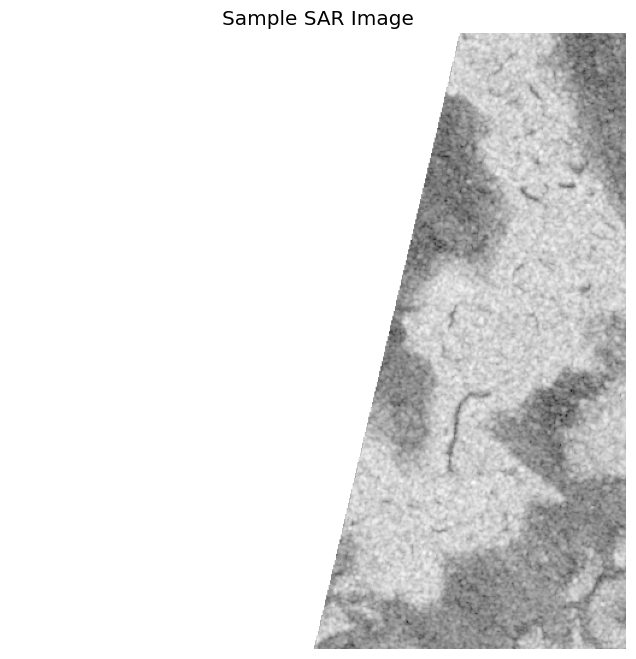

In [ ]:
#VISUALISE SAR IMAGE
plt.figure(figsize=(8,8))
plt.imshow(sar, cmap='gray')
plt.title("Sample SAR Image")
plt.axis("off")
plt.show()

In [ ]:
#corresponding flood mask
sample_mask = mask_images[0]
with rasterio.open(sample_mask) as src:
    mask = src.read(1)
print(mask.shape)

(512, 512)


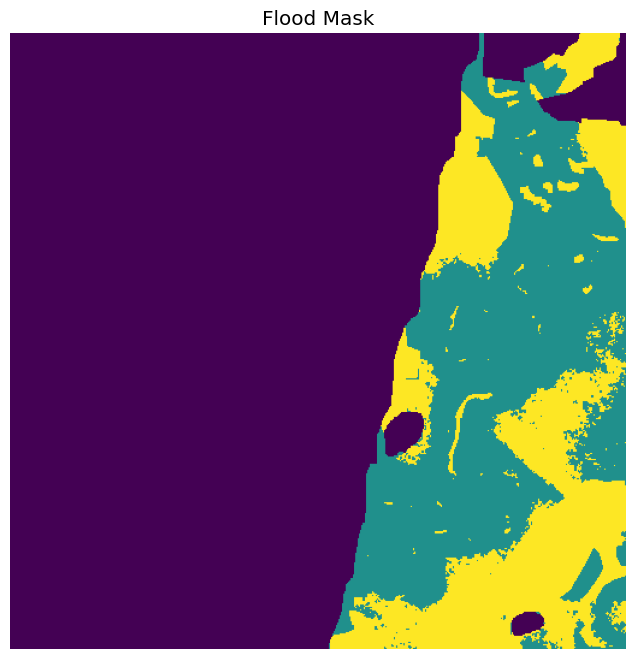

In [ ]:
#VISUALISE FLOOD MASK
plt.figure(figsize=(8,8))
plt.imshow(mask)
plt.title("Flood Mask")
plt.axis("off")
plt.show()

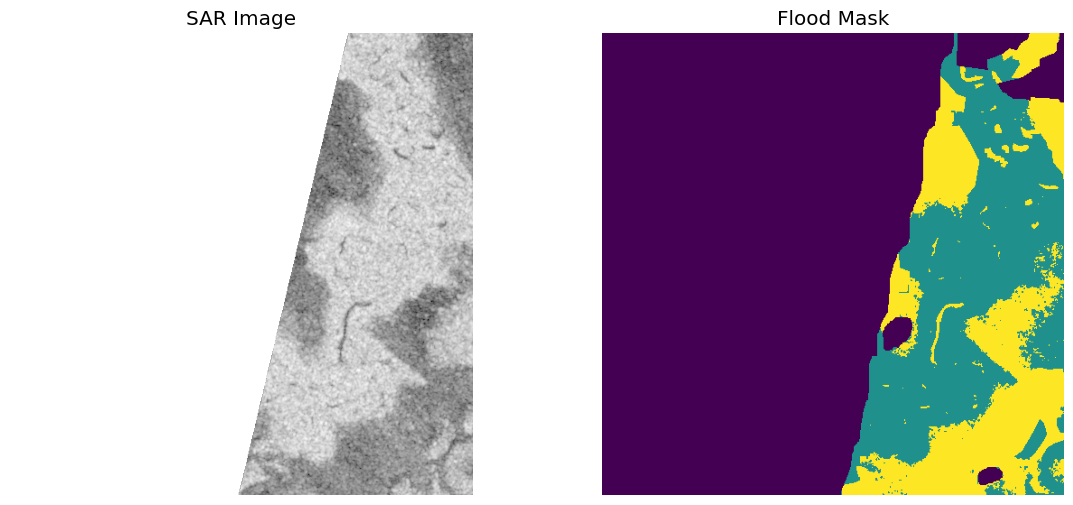

In [ ]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(14,6)
)
ax[0].imshow(
    sar,
    cmap='gray'
)
ax[0].set_title("SAR Image")
ax[0].axis("off")
ax[1].imshow(mask)
ax[1].set_title("Flood Mask")
ax[1].axis("off")
plt.show()

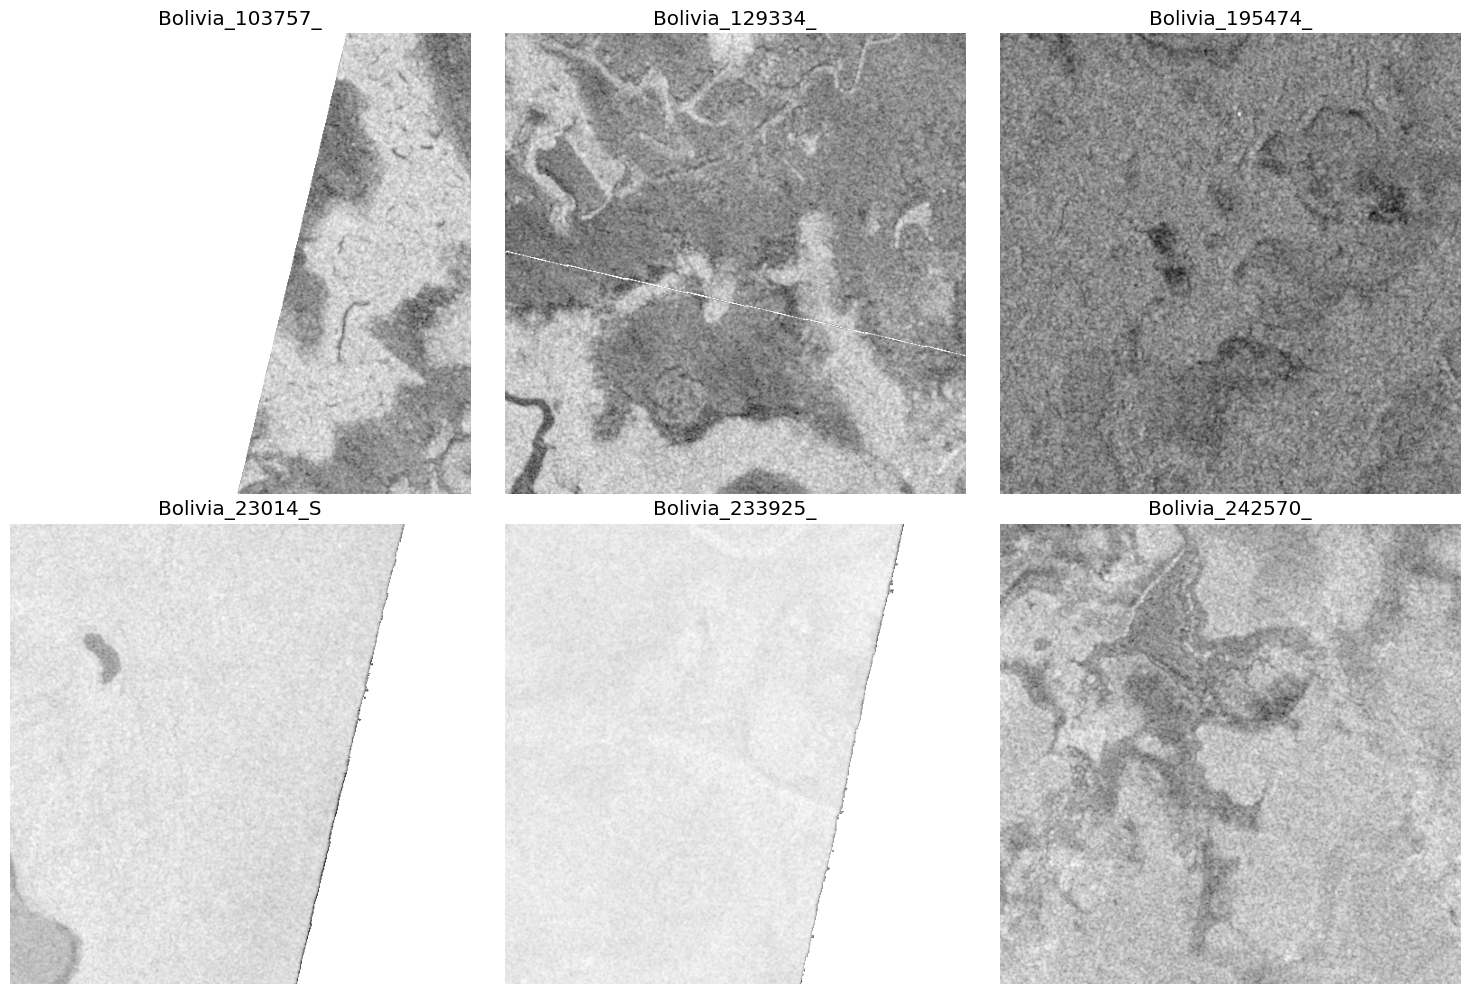

In [ ]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,10)
)

for ax, img_path in zip(
    axes.flatten(),
    sar_images[:6]
):

    with rasterio.open(img_path) as src:
        img = src.read(1)

    ax.imshow(
        img,
        cmap='gray'
    )

    ax.set_title(
        os.path.basename(img_path)[:15]
    )

    ax.axis('off')
plt.tight_layout()
plt.show()

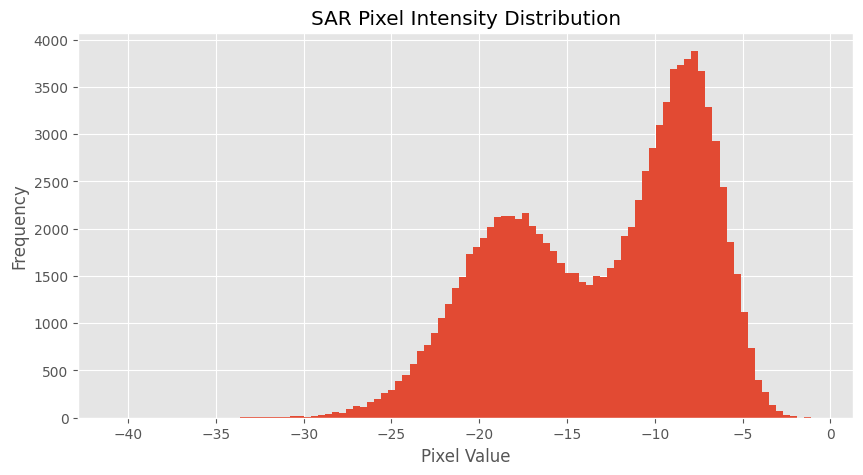

In [ ]:
#PIXEL INTENSITY DISTRIBUTION
plt.figure(figsize=(10,5))
plt.hist(
    sar.flatten(),
    bins=100
)
plt.title(
    "SAR Pixel Intensity Distribution"
)
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#IMAGE DIMENSION CONSISTENCY
dimensions = []
for file in sar_images:
    with rasterio.open(file) as src:
        dimensions.append(src.shape)
pd.Series(
    dimensions
).value_counts()

,count
"(512, 512)",446


In [ ]:
#CLASS DISTRIBUTION
unique_values, counts = np.unique(
    mask,
    return_counts=True
)
class_df = pd.DataFrame({
    "Class": unique_values,
    "Pixels": counts
})
class_df

,Class,Pixels
0,-1,174067
1,0,52715
2,1,35362


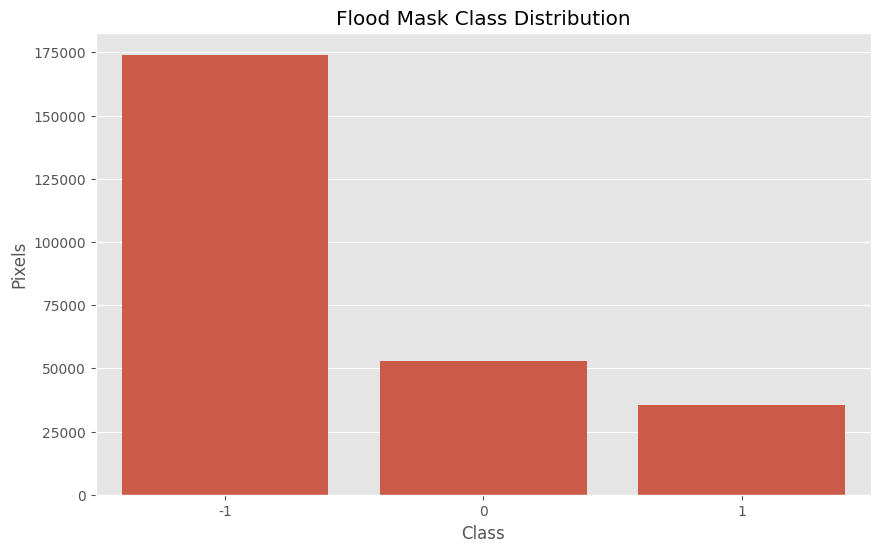

In [ ]:
#FLOOD VS NON FLOOD PLOT
sns.barplot(
    data=class_df,
    x="Class",
    y="Pixels"
)
plt.title(
    "Flood Mask Class Distribution"
)
plt.show()

In [ ]:
#MISSING FILES CHECK
print(
    "Difference:",
    abs(len(sar_images)-len(mask_images))
)

Difference: 0


In [ ]:
#CORRUPTED FILES CHECK
corrupted = []
for file in sar_images:
    try:

        with rasterio.open(file) as src:
            src.read(1)
    except:

        corrupted.append(file)
print(
    "Corrupted Files:",
    len(corrupted)
)

Corrupted Files: 0


In [ ]:
#EMPTY IMAGES CHECK
empty_images = []
for file in sar_images[:100]:

    with rasterio.open(file) as src:

        img = src.read(1)

        if np.sum(img)==0:

            empty_images.append(file)
print(
    "Empty Images:",
    len(empty_images)
)

Empty Images: 0


In [ ]:
#COUNTRY WISE DISTRIBUTION
countries = []

for file in sar_images:

    country = os.path.basename(
        file
    ).split("_")[0]

    countries.append(country)

country_df = pd.Series(
    countries
).value_counts()

country_df.head(15)

,count
USA,69
India,68
Paraguay,67
Ghana,53
Sri-Lanka,42
Spain,30
Mekong,30
Pakistan,28
Somalia,26
Nigeria,18


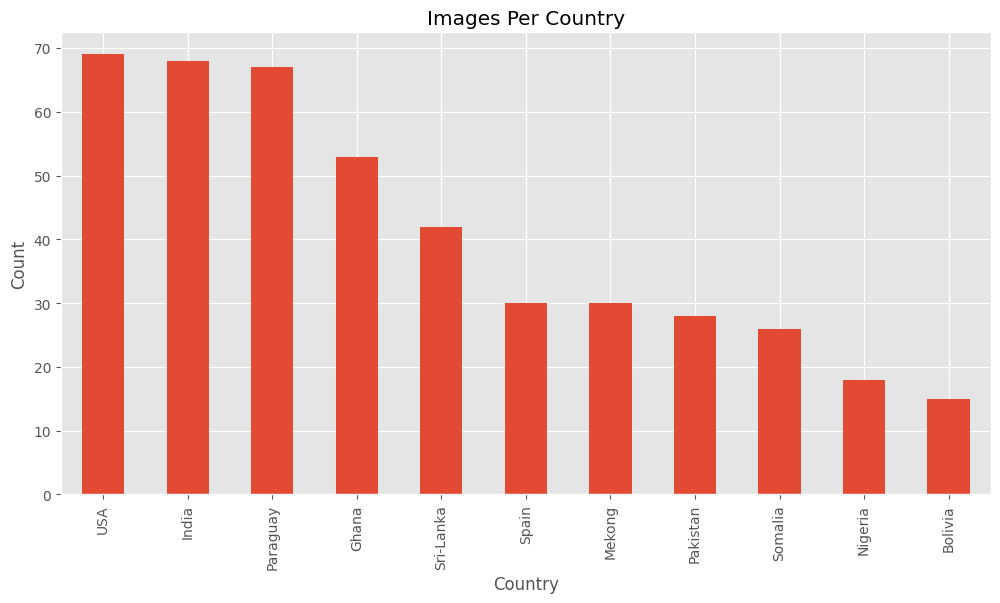

In [ ]:
#COUNTRY WISE PLOT
country_df.plot(
    kind='bar',
    figsize=(12,6)
)
plt.title(
    "Images Per Country"
)
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

# EDA Summary

## Dataset Overview

- Dataset: Sen1Floods11 Essentials
- SAR Images Source: Sentinel-1
- Labels: Hand-Labeled Flood Masks

## Key Findings

- Total SAR Images: ___
- Total Flood Masks: ___
- Most Common Image Size: ___
- Corrupted Files: ___
- Empty Images: ___

## Observations

1. SAR images contain speckle noise.
2. Pixel intensities vary significantly.
3. Flood masks are class-imbalanced.
4. Image dimensions are mostly consistent.
5. Multiple countries contribute to dataset diversity.

## Next Steps

1. Data Cleaning
2. Speckle Noise Reduction
3. Image Normalization
4. Image Resizing
5. Data Augmentation
6. Train-Test Split
7. Label Encoding
8. Autoencoder-Based Image Compression
9. Latent Feature Extraction
10. Flood Detection Model